In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import os

os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

# 2. Set non-TensorFlow seeds
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# 3. Import TensorFlow and set its seed last
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten,BatchNormalization

tf.random.set_seed(42)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

### DataSet

In [2]:
X, y = make_moons(100, noise=0.25,random_state=2) 

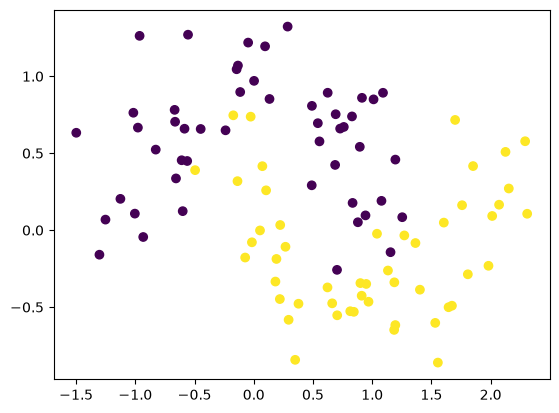

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

###  Without Momentum

In [4]:
model = Sequential([
    Dense(units=128, activation='relu', input_dim=2), 
    Dense(units=1, activation="sigmoid")
])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(loss='binary_crossentropy',  metrics=['accuracy'])

history1 = model.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.6125 - loss: 0.6565 - val_accuracy: 0.8500 - val_loss: 0.6471
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7375 - loss: 0.6281 - val_accuracy: 0.8500 - val_loss: 0.6212
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7500 - loss: 0.6098 - val_accuracy: 0.8500 - val_loss: 0.6003
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7500 - loss: 0.5950 - val_accuracy: 0.8500 - val_loss: 0.5819
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7500 - loss: 0.5821 - val_accuracy: 0.8500 - val_loss: 0.5653
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7625 - loss: 0.5705 - val_accuracy: 0.8500 - val_loss: 0.5498
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7625 - loss: 0.5598 - val_accuracy: 0.9000 - val_loss: 0.5352
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7875 - loss: 0.5499 - val_accuracy: 0.9000 - val_loss: 0.5214

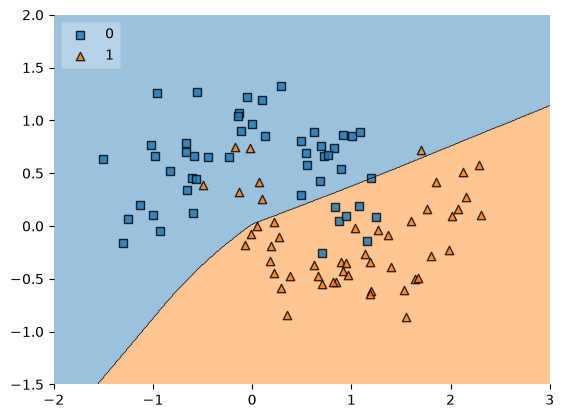

In [7]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

### Using Adagrad

In [8]:
model2 = Sequential([
    Dense(units=128, activation='relu', input_dim=2), 
    Dense(units=1, activation="sigmoid")
])

In [9]:
optimizer=keras.optimizers.Adagrad(
    learning_rate=0.1
)
model2.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history2 = model2.fit(X, y, epochs=50, validation_split = 0.2,verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.5750 - loss: 0.6902 - val_accuracy: 0.8500 - val_loss: 0.6280
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7125 - loss: 0.6123 - val_accuracy: 0.8500 - val_loss: 0.5526
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7500 - loss: 0.5607 - val_accuracy: 0.9000 - val_loss: 0.4935
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7875 - loss: 0.5224 - val_accuracy: 0.9000 - val_loss: 0.4453
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8000 - loss: 0.4931 - val_accuracy: 0.9000 - val_loss: 0.4062
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8125 - loss: 0.4707 - val_accuracy: 0.9000 - val_loss: 0.3751
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8250 - loss: 0.4535 - val_accuracy: 0.9000 - val_loss: 0.3498
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8250 - loss: 0.4402 - val_accuracy: 0.9000 - val_loss: 0.3296

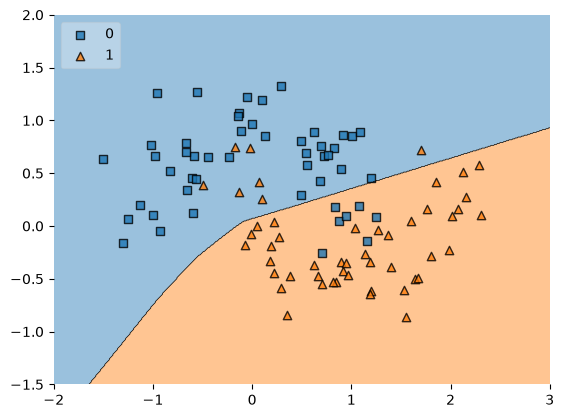

In [10]:
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        preds = self.model.predict(X, verbose=0)
        return (preds > 0.5).astype(int).ravel()  # flatten to 1D int labels

wrapped_model = KerasClassifierWrapper(model2)
plot_decision_regions(X, y.astype(int), clf=wrapped_model, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

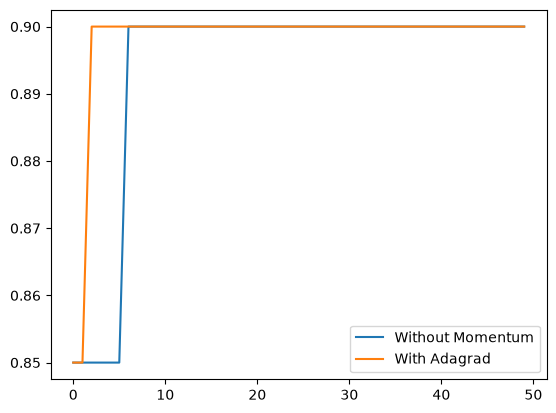

In [13]:
plt.plot(history1.history['val_accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.legend(['Without Momentum', 'With Adagrad'])

plt.show()

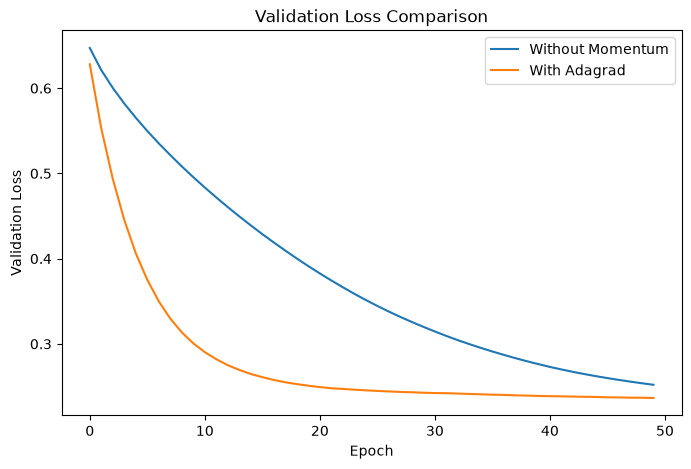

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history1.history['val_loss'], label='Without Momentum')
plt.plot(history2.history['val_loss'], label='With Adagrad')

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

### Conclusion : 
##### Fast Convergence